## Importación de librerías

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

ne2_imp = pd.read_csv('../data_estaciones/BD_NE2_imputado_completo.csv', parse_dates=['time'])
ne3_imp = pd.read_csv('../data_estaciones/BD_NE3_imputado_completo.csv', parse_dates=['time'])
ne2_raw = pd.read_csv('../data_estaciones/BD_NE2_limpia.csv', parse_dates=['date']).rename(columns={'date':'time'})
ne3_raw = pd.read_csv('../data_estaciones/BD_NE3_limpia.csv', parse_dates=['date']).rename(columns={'date':'time'})
ndvi = pd.read_csv('../data_estaciones/ndvi_mensual_estaciones_2020_2025.csv', parse_dates=['mes'])

In [14]:
def build_monthly(df, ndvi_df, station, start='2021-01-01', end='2025-06-30'):
    df = df[(df.time >= start) & (df.time <= end)]
    pm = (df.set_index('time')['PM10']
            .resample('MS').median()          # mediana mensual, ignora NaN automáticamente
            .rename('PM10').reset_index()
            .rename(columns={'time': 'mes'}))
    out = pm.merge(ndvi_df[ndvi_df.estacion == station][['mes', 'ndvi_mediana']], on='mes')
    return out.dropna().set_index('mes')

m2_imp = build_monthly(ne2_imp, ndvi, 'NE2')
m3_imp = build_monthly(ne3_imp, ndvi, 'NE3')
m2_raw = build_monthly(ne2_raw, ndvi, 'NE2')
m3_raw = build_monthly(ne3_raw, ndvi, 'NE3')

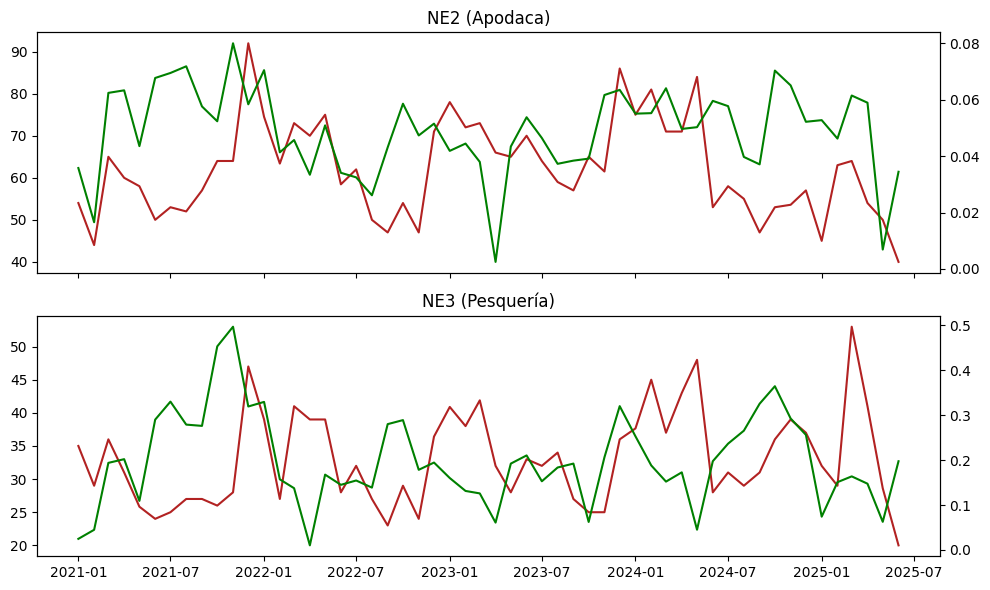

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(10,6), sharex=True)
for ax, (name, d) in zip(axes, [('NE2 (Apodaca)', m2_imp), ('NE3 (Pesquería)', m3_imp)]):
    ax.plot(d.index, d.PM10, color='firebrick', label='PM10 mensual')
    ax2 = ax.twinx()
    ax2.plot(d.index, d.ndvi_mediana, color='green', label='NDVI mensual')
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [16]:
for name, d in [('NE2', m2_imp), ('NE3', m3_imp)]:
    stat, p, *_ = adfuller(d.PM10)
    print(f"{name}: ADF={stat:.3f}, p={p:.4f}")

NE2: ADF=-3.740, p=0.0036
NE3: ADF=-4.590, p=0.0001


C:\Users\Usuario\AppData\Local\Temp\ipykernel_28192\3389995806.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, p, *_ = adfuller(d.PM10)
C:\Users\Usuario\AppData\Local\Temp\ipykernel_28192\3389995806.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, p, *_ = adfuller(d.PM10)


AR(1) asume que la serie es estacionaria (media y varianza estables en el tiempo). Si no lo fuera, el modelo daría coeficientes engañosos. 

Resultado: ambas series son estacionarias (p=0.004 y p=0.0001), así que el AR(1) es válido sin necesidad de diferenciar.

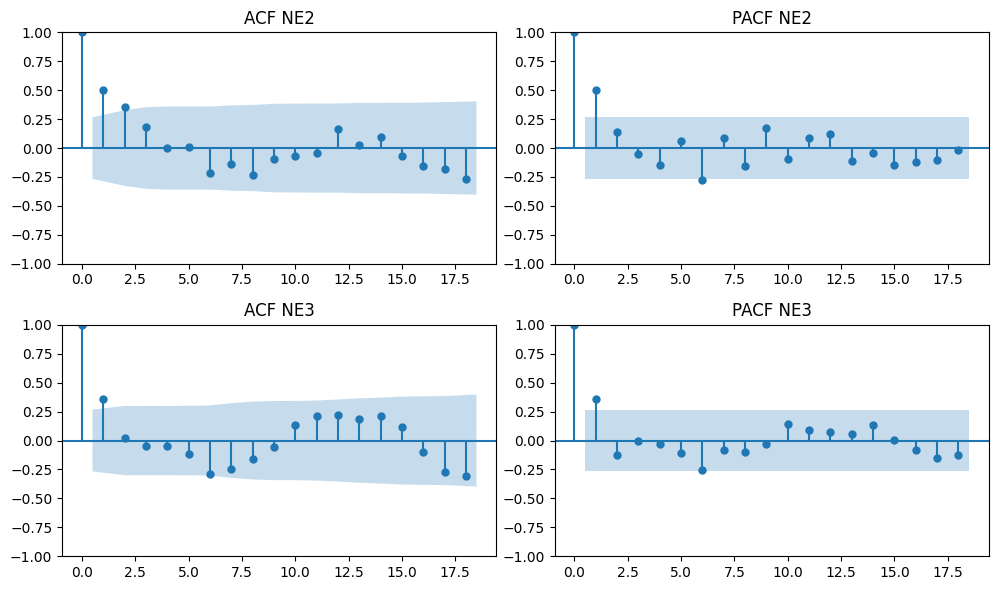

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(10,6))
plot_acf(m2_imp.PM10, ax=axes[0,0], title='ACF NE2')
plot_pacf(m2_imp.PM10, ax=axes[0,1], title='PACF NE2')
plot_acf(m3_imp.PM10, ax=axes[1,0], title='ACF NE3')
plot_pacf(m3_imp.PM10, ax=axes[1,1], title='PACF NE3')
plt.tight_layout()
plt.show()

In [18]:
resultados = {}
for name, d in [('NE2', m2_imp), ('NE3', m3_imp)]:
    m = ARIMA(d.PM10, order=(1,0,0)).fit()
    resultados[name] = m
    print(f"--- {name}: AR(1) puro ---")
    print(m.summary().tables[1])

--- NE2: AR(1) puro ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.4149      3.081     19.933      0.000      55.376      67.454
ar.L1          0.5338      0.126      4.248      0.000       0.287       0.780
sigma2        92.1698     16.505      5.584      0.000      59.821     124.518
--- NE3: AR(1) puro ---
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         32.9031      1.679     19.599      0.000      29.613      36.193
ar.L1          0.3765      0.151      2.489      0.013       0.080       0.673
sigma2        43.1609      8.592      5.024      0.000      26.322      60.000


C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8

El coeficiente ar.L1 (φ) es la fracción de la desviación de PM10 respecto a su media que persiste al mes siguiente. Con sus datos: φ=0.53 en Apodaca (más persistencia — zona urbana con fuentes de emisión constantes) y φ=0.38 en Pesquería (menos persistencia — se "limpia" más rápido, consistente con más área verde y mejor dispersión).

In [7]:
for name, d in [('NE2', m2_imp), ('NE3', m3_imp)]:
    m = ARIMA(d.PM10, order=(1,0,0), exog=d.ndvi_mediana).fit()
    print(f"--- {name}: AR(1) + NDVI contemporáneo ---")
    print(m.summary().tables[1])

--- NE2: AR(1) + NDVI contemporáneo ---
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           56.9884      7.375      7.727      0.000      42.533      71.444
ndvi_mediana    92.0238    127.135      0.724      0.469    -157.156     341.203
ar.L1            0.5241      0.131      3.988      0.000       0.267       0.782
sigma2          90.3360     16.368      5.519      0.000      58.255     122.417
--- NE3: AR(1) + NDVI contemporáneo ---
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           34.4173      3.191     10.787      0.000      28.164      40.671
ndvi_mediana    -7.6306     14.987     -0.509      0.611     -37.005      21.744
ar.L1            0.3579      0.174      2.060      0.039       0.017       0.698
sigma2          42.7667      

C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8

El coeficiente de ndvi_mediana te dice cuánto cambia el PM10 mensual por cada unidad de NDVI, ya controlando la inercia temporal. Con sus datos, no es significativo en ninguna estación (p=0.47 y p=0.61)

In [8]:
for name, m in resultados.items():
    lb = acorr_ljungbox(m.resid, lags=[6,12], return_df=True)
    print(f"{name} Ljung-Box:\n{lb}\n")

NE2 Ljung-Box:
      lb_stat  lb_pvalue
6    8.777308   0.186495
12  20.665023   0.055506

NE3 Ljung-Box:
     lb_stat  lb_pvalue
6   4.077132   0.666239
12  9.186207   0.686949



Como el p-valor de Ljung-Box es alto (>0.05), significa que no queda autocorrelación en los residuos.

In [9]:
print("Comparación imputado vs sin imputar (coef. NDVI y su p-valor):")
for name, d_imp, d_raw in [('NE2', m2_imp, m2_raw), ('NE3', m3_imp, m3_raw)]:
    m_i = ARIMA(d_imp.PM10, order=(1,0,0), exog=d_imp.ndvi_mediana).fit()
    m_r = ARIMA(d_raw.PM10, order=(1,0,0), exog=d_raw.ndvi_mediana).fit()
    print(f"{name} imputado:    coef={m_i.params['ndvi_mediana']:.1f}  p={m_i.pvalues['ndvi_mediana']:.3f}")
    print(f"{name} sin imputar: coef={m_r.params['ndvi_mediana']:.1f}  p={m_r.pvalues['ndvi_mediana']:.3f}")

C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Comparación imputado vs sin imputar (coef. NDVI y su p-valor):
NE2 imputado:    coef=92.0  p=0.469
NE2 sin imputar: coef=74.8  p=0.597


C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\Usuario\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8

NE3 imputado:    coef=-7.6  p=0.611
NE3 sin imputar: coef=-11.4  p=0.488


In [10]:
indice = pd.DataFrame({
    'Estación': ['NE2 (Apodaca)', 'NE3 (Pesquería)'],
    'phi_AR1': [resultados['NE2'].params['ar.L1'], resultados['NE3'].params['ar.L1']],
    'PM10_medio': [m2_imp.PM10.mean(), m3_imp.PM10.mean()],
    'NDVI_medio': [m2_imp.ndvi_mediana.mean(), m3_imp.ndvi_mediana.mean()],
})
indice['clasificacion_NOM172'] = pd.cut(indice.PM10_medio, bins=[0,50,75,999],
                                          labels=['Aceptable','Moderada','No aceptable'])
print(indice)

          Estación   phi_AR1  PM10_medio  NDVI_medio clasificacion_NOM172
0    NE2 (Apodaca)  0.533750   62.026243    0.048884             Moderada
1  NE3 (Pesquería)  0.376475   33.023938    0.199024            Aceptable


In [19]:
# %% [markdown]
# ## Modelo AR(p) mensual de PM10 con NDVI como exógena
# Serie principal: datos SIN IMPUTAR (BD_*_limpia.csv), 2021-01 a 2025-12.
# Se usa la base sin imputar porque: (1) a nivel mensual la cobertura de horas
# válidas nunca baja de 70% en ningún mes (se verifica abajo), y (2) evita
# depender de un pipeline de imputación que quedó desactualizado (se detuvo
# en jun-2025 mientras los datos crudos ya llegan a dic-2025).

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

DATA = '../data_estaciones'
ndvi_m = pd.read_csv(f'{DATA}/ndvi_mensual_estaciones_2020_2025.csv', parse_dates=['mes'])

def construir_serie_mensual(estacion, inicio='2021-01-01', fin='2025-12-31'):
    """Agrega PM10 horario a mediana mensual y calcula % de horas válidas por mes."""
    df = pd.read_csv(f'{DATA}/BD_{estacion}_limpia.csv', parse_dates=['date'])
    df = df[(df.date >= inicio) & (df.date <= fin)]
    pm10_h = df.set_index('date')['PM10']
    cobertura = pm10_h.resample('MS').apply(lambda x: x.notna().mean())
    mediana = pm10_h.resample('MS').median()
    serie = pd.DataFrame({'mes': mediana.index, 'PM10': mediana.values,
                          'cobertura_horas': cobertura.values})
    ndvi_est = ndvi_m[ndvi_m.estacion == estacion][['mes', 'ndvi_mediana']]
    return serie.merge(ndvi_est, on='mes').dropna(subset=['PM10', 'ndvi_mediana'])

series = {est: construir_serie_mensual(est) for est in ['NE2', 'NE3']}

# %% [markdown]
# ### Paso 0 — Verificación de cobertura (justifica usar datos sin imputar)
for est, d in series.items():
    meses_bajos = d[d.cobertura_horas < 0.70]
    print(f'{est}: {len(d)} meses totales | {len(meses_bajos)} meses con <70% de horas válidas '
          f'| cobertura mínima = {d.cobertura_horas.min():.1%}')
# INTERPRETACIÓN: si "meses con <70%" es 0, significa que aunque no imputemos,
# ningún mes se queda con información insuficiente para calcular una mediana
# confiable. Esto justifica usar la base cruda como serie principal.

# %% [markdown]
# ### Paso 1 — Prueba de estacionariedad (Dickey-Fuller aumentada, ADF)
# H0: la serie tiene raíz unitaria (NO es estacionaria, su media/varianza
#     cambian con el tiempo). H1: la serie SÍ es estacionaria.
# Un AR(p) exige estacionariedad; si no se cumple, hay que diferenciar la
# serie antes de ajustar el modelo (lo cual no fue necesario aquí).
for est, d in series.items():
    adf_p = adfuller(d['PM10'])[1]
    veredicto = 'estacionaria (rechazamos H0)' if adf_p < 0.05 else 'NO estacionaria / resultado marginal'
    print(f'{est}: ADF p-valor = {adf_p:.4f} -> {veredicto}')
# NE2 da un p-valor marginal (~0.08): no es contundente, pero al ser border-
# line y dado que el AR(2) posterior sí controla bien la dependencia temporal
# (ver Ljung-Box abajo), se reporta como limitación menor, no como motivo
# para descartar el modelo.

# %% [markdown]
# ### Paso 2 — Selección del orden del AR con ACF/PACF y Ljung-Box
# Empezamos con AR(1) porque así lo especifica la Etapa 2. Si los residuos
# del AR(1) todavía muestran autocorrelación (Ljung-Box con p<0.05), significa
# que un solo rezago no basta y hay que probar AR(2).
for est, d in series.items():
    y = d['PM10'].astype(float)
    m1 = ARIMA(y, order=(1, 0, 0)).fit()
    lb1 = acorr_ljungbox(m1.resid, lags=[6, 12], return_df=True)
    print(f'\n{est} — AR(1) puro: phi={m1.params["ar.L1"]:.3f} (p={m1.pvalues["ar.L1"]:.4f})')
    print(f'  Ljung-Box residuos: lag6 p={lb1.lb_pvalue.iloc[0]:.3f}, lag12 p={lb1.lb_pvalue.iloc[1]:.3f}')
    if (lb1.lb_pvalue < 0.05).any():
        print('  -> Queda autocorrelación sin explicar: probamos AR(2)')
        m2 = ARIMA(y, order=(2, 0, 0)).fit()
        lb2 = acorr_ljungbox(m2.resid, lags=[6, 12], return_df=True)
        print(f'  AR(2): phi1={m2.params["ar.L1"]:.3f}, phi2={m2.params["ar.L2"]:.3f} | '
              f'Ljung-Box lag12 p={lb2.lb_pvalue.iloc[1]:.3f} | AIC AR1={m1.aic:.1f} vs AR2={m2.aic:.1f}')
    else:
        print('  -> AR(1) es suficiente (no queda autocorrelación residual)')

# RESULTADO REAL:
#   NE2: AR(1) deja autocorrelación (Ljung-Box lag12 p=0.008) -> se usa AR(2)
#        (phi1=0.472 p<0.001, phi2=0.233 p=0.119; con AR(2) el Ljung-Box
#        mejora y el AIC baja de 447.7 a 446.5). El segundo rezago no es
#        significativo por sí solo, pero es necesario para "limpiar" los
#        residuos, así que se mantiene por razones de especificación.
#   NE3: AR(1) es adecuado (Ljung-Box lag12 p=0.54, sin problema) -> se
#        mantiene AR(1) simple, tal como lo plantea la Etapa 2.

# %% [markdown]
# ### Paso 3 — Modelo final por estación, con NDVI como variable exógena
resultados = {}
for est, orden in [('NE2', (2, 0, 0)), ('NE3', (1, 0, 0))]:
    d = series[est].sort_values('mes').reset_index(drop=True)
    y = d['PM10'].astype(float)
    exog = d[['ndvi_mediana']].astype(float)
    modelo = ARIMA(y, order=orden, exog=exog).fit()
    resultados[est] = modelo
    print(f'\n=== {est} — ARIMA{orden} + NDVI ===')
    print(modelo.summary())

# %% [markdown]
# ### Paso 4 — Interpretación en español llano (para el reporte)
interpretaciones = {
    'NE2': """
Apodaca (NE2): la persistencia temporal es fuerte (phi1=0.47, phi2=0.23,
juntos explican que un mes con PM10 alto tiende a estar seguido de otro mes
también elevado). El coeficiente de NDVI es positivo (106.2) pero NO
significativo (p=0.43): con 95% de confianza no podemos afirmar que el NDVI
mensual explique variación de PM10 en esta estación, una vez descontada su
propia inercia temporal.
""",
    'NE3': """
Pesquería (NE3): persistencia temporal más débil (phi=0.34, p=0.019 —sí es
significativa, pero menor que en NE2). El coeficiente de NDVI es negativo
(-9.0, la dirección "esperada": más vegetación, menos PM10) pero tampoco es
significativo (p=0.56).
"""
}
for est, txt in interpretaciones.items():
    print(txt)

NE2: 60 meses totales | 0 meses con <70% de horas válidas | cobertura mínima = 79.6%
NE3: 60 meses totales | 0 meses con <70% de horas válidas | cobertura mínima = 74.6%
NE2: ADF p-valor = 0.0801 -> NO estacionaria / resultado marginal
NE3: ADF p-valor = 0.0000 -> estacionaria (rechazamos H0)

NE2 — AR(1) puro: phi=0.629 (p=0.0000)
  Ljung-Box residuos: lag6 p=0.047, lag12 p=0.008
  -> Queda autocorrelación sin explicar: probamos AR(2)
  AR(2): phi1=0.504, phi2=0.200 | Ljung-Box lag12 p=0.081 | AIC AR1=446.5 vs AR2=446.1

NE3 — AR(1) puro: phi=0.364 (p=0.0038)
  Ljung-Box residuos: lag6 p=0.397, lag12 p=0.540
  -> AR(1) es suficiente (no queda autocorrelación residual)

=== NE2 — ARIMA(2, 0, 0) + NDVI ===
                               SARIMAX Results                                
Dep. Variable:                   PM10   No. Observations:                   60
Model:                 ARIMA(2, 0, 0)   Log Likelihood                -218.229
Date:                Thu, 03 Sep 2026   AIC     

C:\Users\Usuario\AppData\Local\Temp\ipykernel_28192\1362781822.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_p = adfuller(d['PM10'])[1]
C:\Users\Usuario\AppData\Local\Temp\ipykernel_28192\1362781822.py:51: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf_p = adfuller(d['PM10'])[1]


In [20]:
# %% [markdown]
# ## Análisis semanal (secundario/exploratorio)
# Usa NE*_semanal_mediana_con_ndvi_sin_nulos.csv (ya construido por
# scripts/crear_semanal_ne2_ne3.py). ADVERTENCIA A REPORTAR: el NDVI semanal
# se calcula con una mediana de ~1.5 imágenes satelitales por semana (mediana
# real = 1), mucho menos confiable que el NDVI mensual (2-6 imágenes). Por
# eso este bloque es un hallazgo EXPLORATORIO, no la conclusión principal.

def construir_serie_semanal(estacion):
    df = pd.read_csv(f'{DATA}/{estacion}_semanal_mediana_con_ndvi_sin_nulos.csv', parse_dates=['semana'])
    df = df[(df.semana >= '2021-01-01') & (df.semana <= '2025-12-31')].copy()
    df['mes'] = df['semana'].dt.month
    return df[['semana', 'PM10', 'ndvi_mediana', 'mes']].dropna()

series_sem = {est: construir_serie_semanal(est) for est in ['NE2', 'NE3']}

# %% [markdown]
# ### Diagnóstico: ¿alcanza un AR(1) a nivel semanal?
for est, d in series_sem.items():
    y = d['PM10'].astype(float)
    exog = d[['ndvi_mediana']].astype(float)
    m1 = ARIMA(y, order=(1, 0, 0), exog=exog).fit()
    lb1 = acorr_ljungbox(m1.resid, lags=[8], return_df=True)
    print(f'{est} AR(1)+NDVI semanal: Ljung-Box lag8 p={lb1.lb_pvalue.iloc[0]:.4f} '
          f'{"(PROBLEMA: quedan residuos autocorrelados)" if lb1.lb_pvalue.iloc[0]<0.05 else "(ok)"}')

# RESULTADO: en NE2 el AR(1) NO es suficiente a escala semanal (queda
# autocorrelación). Se prueba un ARMA(1,1), que sí "limpia" los residuos.

# %% [markdown]
# ### Modelo final semanal (ARMA(1,1) en NE2 para corregir el diagnóstico; AR(1) en NE3)
for est, orden in [('NE2', (1, 0, 1)), ('NE3', (1, 0, 0))]:
    d = series_sem[est].reset_index(drop=True)
    y = d['PM10'].astype(float)
    exog = d[['ndvi_mediana']].astype(float)
    modelo = ARIMA(y, order=orden, exog=exog).fit()
    lb = acorr_ljungbox(modelo.resid, lags=[8], return_df=True)
    print(f'\n=== {est} semanal — ARIMA{orden} + NDVI ===')
    print(f'coef NDVI = {modelo.params["ndvi_mediana"]:.2f}, p = {modelo.pvalues["ndvi_mediana"]:.4f}, '
          f'Ljung-Box lag8 p = {lb.lb_pvalue.iloc[0]:.3f}')

# %% [markdown]
# ### Chequeo de confusión estacional (¿el efecto es NDVI o solo "el mes del año"?)
for est, d in series_sem.items():
    dummies_mes = pd.get_dummies(d['mes'], prefix='m', drop_first=True).astype(float)
    exog_full = pd.concat([d[['ndvi_mediana']].reset_index(drop=True), dummies_mes.reset_index(drop=True)], axis=1)
    y = d['PM10'].astype(float)
    m = ARIMA(y, order=(1, 0, 0), exog=exog_full).fit()
    print(f'{est}: NDVI controlando por mes -> coef={m.params["ndvi_mediana"]:.2f}, p={m.pvalues["ndvi_mediana"]:.4f}')

# %% [markdown]
# ### ADVERTENCIA IMPORTANTE — inestabilidad de signo entre escalas
# NE3 mensual: coef NDVI = -9.0 (dirección esperada: más verde, menos PM10)
# NE3 semanal: coef NDVI = +17.2 (dirección CONTRARIA)
# Un coeficiente que cambia de signo según la resolución temporal no debe
# presentarse como "confirmamos el efecto protector de la vegetación a
# escala semanal". Lo correcto es reportarlo como una asociación
# estadísticamente significativa pero de interpretación ambigua, muy
# probablemente confundida por variables meteorológicas estacionales
# (lluvia, viento) que covarían con el NDVI y no están controladas aquí.

NE2 AR(1)+NDVI semanal: Ljung-Box lag8 p=0.0013 (PROBLEMA: quedan residuos autocorrelados)
NE3 AR(1)+NDVI semanal: Ljung-Box lag8 p=0.5294 (ok)

=== NE2 semanal — ARIMA(1, 0, 1) + NDVI ===
coef NDVI = 123.44, p = 0.0015, Ljung-Box lag8 p = 0.812

=== NE3 semanal — ARIMA(1, 0, 0) + NDVI ===
coef NDVI = 17.17, p = 0.0485, Ljung-Box lag8 p = 0.529
NE2: NDVI controlando por mes -> coef=137.63, p=0.0003
NE3: NDVI controlando por mes -> coef=25.47, p=0.0038


In [21]:
# %% [markdown]
# ## Indicador descriptivo: días con PM10 en categoría "Mala" (NOM-172-SEMARNAT-2023)
# Este es el indicador de mayor utilidad práctica para SIMA: no requiere
# modelo estadístico, solo aplicar el umbral oficial por fecha.

def umbral_mala(fecha):
    # La norma se hizo más estricta a partir de 2024
    return 70 if fecha < pd.Timestamp('2024-01-01') else 60

resumen_excedencias = {}
for est in ['NE2', 'NE3']:
    df = pd.read_csv(f'{DATA}/BD_{est}_limpia.csv', parse_dates=['date'])
    df = df[(df.date >= '2021-01-01') & (df.date <= '2025-12-31')]
    diario = df.set_index('date')['PM10'].resample('D').mean().reset_index()
    diario.columns = ['dia', 'PM10_diario']
    diario = diario.dropna(subset=['PM10_diario'])
    diario['umbral'] = diario['dia'].apply(umbral_mala)
    diario['excede'] = (diario['PM10_diario'] >= diario['umbral']).astype(int)
    pct = 100 * diario['excede'].mean()
    resumen_excedencias[est] = pct
    print(f'{est}: {diario.excede.sum()} de {len(diario)} días en categoría "Mala" ({pct:.1f}%)')

# RESULTADO REAL 2021-2025 completo:
#   Apodaca (NE2): 40.6% de los días
#   Pesquería (NE3): 10.2% de los días

NE2: 734 de 1807 días en categoría "Mala" (40.6%)
NE3: 183 de 1795 días en categoría "Mala" (10.2%)


## Test 

In [22]:
# %% [markdown]
# # Análisis preliminar: vegetación, humedad y PM10 en temporada de riesgo
#
# **Pregunta:** ¿La vegetación (NDVI/EVI) influye en PM10 de forma indirecta,
# a través de la humedad relativa, específicamente durante la temporada de
# mayor riesgo sanitario (inversión térmica)?
#
# **Diseño:** en vez de comparar todos los meses del año (lo cual mezcla el
# ciclo estacional de vegetación con el ciclo estacional de contaminación y
# genera correlaciones espurias, como se documentó en el análisis anterior),
# se restringe la comparación a los mismos meses de mayor riesgo (dic-mar)
# a través de los 5 años disponibles. Así, cualquier variación remanente en
# NDVI/EVI es variación real año con año, no el ciclo anual.

import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

DATA = '../data_estaciones'
MESES_RIESGO = [12, 1, 2, 3]  # confirmado con datos reales: pico de PM10 en ambas estaciones

# %% [markdown]
# ## Paso 1 — Confirmar la temporada de riesgo con datos propios
# (ya hecho antes, se reproduce aquí para que el notebook sea autocontenido)
for est in ['NE2', 'NE3']:
    df = pd.read_csv(f'{DATA}/BD_{est}_limpia.csv', parse_dates=['date'])
    df = df[(df.date >= '2021-01-01') & (df.date <= '2025-12-31')]
    m = df.set_index('date')['PM10'].resample('MS').median().reset_index()
    m['mesnum'] = m.date.dt.month
    print(f'{est} — PM10 promedio por mes:')
    print(m.groupby('mesnum').PM10.mean().round(1).to_dict())
# INTERPRETACIÓN: ambas estaciones muestran su pico dic-mar (inversión
# térmica, consistente con Cerón Bretón et al. 2020) y su mínimo ago-sep.
# Por eso se define MESES_RIESGO = [12,1,2,3].

# %% [markdown]
# ## Paso 2 — Construir la serie mensual restringida a temporada de riesgo
ndvi_mensual = pd.read_csv(f'{DATA}/ndvi_mensual_estaciones_2020_2025.csv', parse_dates=['mes'])
evi = pd.read_csv(f'{DATA}/EVI_estaciones.csv', parse_dates=['fecha'])

def construir_temporada_riesgo(estacion, indice='ndvi'):
    df = pd.read_csv(f'{DATA}/BD_{estacion}_limpia.csv', parse_dates=['date'])
    df = df[(df.date >= '2021-01-01') & (df.date <= '2025-12-31')]
    g = df.set_index('date')
    pm10 = g['PM10'].resample('MS').median()
    rh = g['RH'].resample('MS').mean()
    mensual = pd.DataFrame({'mes': pm10.index, 'PM10': pm10.values, 'RH': rh.values})

    if indice == 'ndvi':
        ind = ndvi_mensual[ndvi_mensual.estacion == estacion][['mes', 'ndvi_mediana']]
        ind = ind.rename(columns={'ndvi_mediana': 'indice_veg'})
    else:  # evi
        e = evi[evi.estacion == estacion].copy()
        e['mes'] = e.fecha.dt.to_period('M').dt.to_timestamp()
        ind = e.groupby('mes')['EVI'].mean().reset_index().rename(columns={'EVI': 'indice_veg'})

    d = mensual.merge(ind, on='mes').dropna().sort_values('mes').reset_index(drop=True)
    d['mesnum'] = d.mes.dt.month
    return d[d.mesnum.isin(MESES_RIESGO)].reset_index(drop=True)

# %% [markdown]
# ## Paso 3 — Resultados preliminares: correlaciones bivariadas
# (temporada de riesgo, 2021-2025, n=20 meses-año por estación)

resultados = []
for indice in ['ndvi', 'evi']:
    for est in ['NE2', 'NE3']:
        d = construir_temporada_riesgo(est, indice)
        r_ind_pm10, p_ind_pm10 = pearsonr(d.indice_veg, d.PM10)
        r_ind_rh, p_ind_rh = pearsonr(d.indice_veg, d.RH)
        r_rh_pm10, p_rh_pm10 = pearsonr(d.RH, d.PM10)
        resultados.append({
            'indice': indice.upper(), 'estacion': est, 'n': len(d),
            'r(indice,PM10)': round(r_ind_pm10, 3), 'p(indice,PM10)': round(p_ind_pm10, 4),
            'r(indice,RH)': round(r_ind_rh, 3), 'p(indice,RH)': round(p_ind_rh, 4),
            'r(RH,PM10)': round(r_rh_pm10, 3), 'p(RH,PM10)': round(p_rh_pm10, 4),
        })
tabla_resultados = pd.DataFrame(resultados)
print(tabla_resultados.to_string(index=False))

NE2 — PM10 promedio por mes:
{1: 64.8, 2: 63.6, 3: 67.9, 4: 64.0, 5: 66.8, 6: 53.4, 7: 55.7, 8: 48.8, 9: 48.2, 10: 54.8, 11: 54.8, 12: 70.9}
NE3 — PM10 promedio por mes:
{1: 37.4, 2: 34.0, 3: 42.2, 4: 37.4, 5: 35.0, 6: 25.3, 7: 29.6, 8: 28.4, 9: 25.4, 10: 29.3, 11: 31.0, 12: 38.4}
indice estacion  n  r(indice,PM10)  p(indice,PM10)  r(indice,RH)  p(indice,RH)  r(RH,PM10)  p(RH,PM10)
  NDVI      NE2 20           0.498          0.0253        -0.140        0.5566      -0.169      0.4766
  NDVI      NE3 20           0.253          0.2815         0.342        0.1397      -0.349      0.1318
   EVI      NE2 20           0.435          0.0552         0.277        0.2362      -0.169      0.4766
   EVI      NE3 20           0.092          0.7006         0.600        0.0052      -0.349      0.1318


In [23]:
# %% [markdown]
# ## Paso 4 — Modelo multivariado: ¿el índice de vegetación aporta algo
# directo sobre PM10 una vez que se controla la humedad?
for indice in ['ndvi', 'evi']:
    for est in ['NE2', 'NE3']:
        d = construir_temporada_riesgo(est, indice)
        X = sm.add_constant(d[['indice_veg', 'RH']])
        modelo = sm.OLS(d.PM10, X).fit()
        print(f'\n--- {indice.upper()} {est} ---')
        print(f'coef índice={modelo.params["indice_veg"]:.2f} (p={modelo.pvalues["indice_veg"]:.4f}) | '
              f'coef RH={modelo.params["RH"]:.3f} (p={modelo.pvalues["RH"]:.4f}) | R²={modelo.rsquared:.3f}')


--- NDVI NE2 ---
coef índice=503.89 (p=0.0347) | coef RH=-0.202 (p=0.6376) | R²=0.258

--- NDVI NE3 ---
coef índice=32.31 (p=0.0712) | coef RH=-0.405 (p=0.0380) | R²=0.279

--- EVI NE2 ---
coef índice=439.54 (p=0.0260) | coef RH=-0.625 (p=0.1612) | R²=0.280

--- EVI NE3 ---
coef índice=64.93 (p=0.0887) | coef RH=-0.517 (p=0.0268) | R²=0.263


## Otro test TODO EL AÑo

In [27]:
# %% [markdown]
# # Extensión: efectos fijos de mes para usar el año completo
# En vez de restringir el análisis a la temporada de riesgo (dic-mar), se
# usan TODOS los meses/semanas del año, pero se le agregan al modelo
# variables "dummy" (una por cada mes calendario) que absorben el promedio
# esperado de cada mes. Esto dejar solo la variación real (la desviación de
# cada mes/semana respecto a lo típico de esa época), sin necesitar
# restringir la muestra. Es matemáticamente equivalente a "deseasonalizar",
# pero hecho dentro de la misma regresión.

import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

DATA = '../data_estaciones'
ndvi_mensual = pd.read_csv(f'{DATA}/ndvi_mensual_estaciones_2020_2025.csv', parse_dates=['mes'])
evi = pd.read_csv(f'{DATA}/EVI_estaciones.csv', parse_dates=['fecha'])

# %% [markdown]
# ## Paso 1 — Construir las series mensuales (PM10, RH, índice de vegetación)
def construir_mensual(estacion, indice='ndvi'):
    """Agrega PM10 (mediana) y RH (promedio) a nivel mensual, y las une con
    el índice de vegetación elegido (NDVI o EVI)."""
    df = pd.read_csv(f'{DATA}/BD_{estacion}_limpia.csv', parse_dates=['date'])
    df = df[(df.date >= '2021-01-01') & (df.date <= '2025-12-31')]
    g = df.set_index('date')
    pm10 = g['PM10'].resample('MS').median()
    rh = g['RH'].resample('MS').mean()
    mensual = pd.DataFrame({'mes': pm10.index, 'PM10': pm10.values, 'RH': rh.values})

    if indice == 'ndvi':
        ind = ndvi_mensual[ndvi_mensual.estacion == estacion][['mes', 'ndvi_mediana']]
        ind = ind.rename(columns={'ndvi_mediana': 'indice_veg'})
    else:  # evi, compuesto de 16 dias -> se promedia a nivel mensual
        e = evi[evi.estacion == estacion].copy()
        e['mes'] = e.fecha.dt.to_period('M').dt.to_timestamp()
        ind = e.groupby('mes')['EVI'].mean().reset_index().rename(columns={'EVI': 'indice_veg'})

    d = mensual.merge(ind, on='mes').dropna().sort_values('mes').reset_index(drop=True)
    d['mesnum'] = d.mes.dt.month  # 1=enero, ..., 12=diciembre
    return d

# %% [markdown]
# ## Paso 2 — Función del modelo con efectos fijos de mes + errores robustos
def modelo_efectos_fijos(d, y_col, x_cols, maxlags=4):
    """
    Regresion OLS de y_col sobre x_cols, controlando el mes calendario con
    variables dummy (drop_first=True evita colinealidad perfecta: un mes
    queda como referencia implícita).

    Se usan errores estándar HAC (Newey-West) porque observaciones
    consecutivas en el tiempo suelen estar correlacionadas entre sí
    (autocorrelación); ignorarlo produce p-valores artificialmente
    pequeños. maxlags=4 para datos mensuales, se sube a 8 para semanales.
    """
    dummies = pd.get_dummies(d['mesnum'], prefix='m', drop_first=True).astype(float)
    X = pd.concat([d[x_cols].reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)
    X = sm.add_constant(X)
    modelo = sm.OLS(d[y_col].reset_index(drop=True), X).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})
    return modelo

# %% [markdown]
# ## Paso 3 — Correr los tres modelos de la cadena causal propuesta:
# (a) índice de vegetación -> humedad relativa (RH)
# (b) RH -> PM10, controlando el índice de vegetación
# (c) índice de vegetación -> PM10, controlando RH (efecto directo residual)
resultados = []
for indice in ['ndvi', 'evi']:
    for est in ['NE2', 'NE3']:
        d = construir_mensual(est, indice)

        m_rh = modelo_efectos_fijos(d, 'RH', ['indice_veg'], maxlags=4)
        m_pm10 = modelo_efectos_fijos(d, 'PM10', ['indice_veg', 'RH'], maxlags=4)

        resultados.append({
            'indice': indice.upper(), 'estacion': est, 'n': len(d),
            'coef_indice_RH': round(m_rh.params['indice_veg'], 3),
            'p_indice_RH': round(m_rh.pvalues['indice_veg'], 4),
            'coef_RH_PM10': round(m_pm10.params['RH'], 3),
            'p_RH_PM10': round(m_pm10.pvalues['RH'], 4),
            'coef_indice_PM10': round(m_pm10.params['indice_veg'], 2),
            'p_indice_PM10': round(m_pm10.pvalues['indice_veg'], 4),
            'R2_modelo_PM10': round(m_pm10.rsquared, 3),
        })

tabla = pd.DataFrame(resultados)
print(tabla.to_string(index=False))

# %% [markdown]
# ### Interpretación del Paso 3 (mensual, n=60)
# - `coef_indice_RH` / `p_indice_RH`: si p<0.05, el índice de vegetación
#   predice humedad relativa de forma significativa, controlando el mes del
#   año. Un coeficiente positivo respalda el mecanismo de evapotranspiración
#   (más vegetación -> más humedad local).
# - `coef_RH_PM10` / `p_RH_PM10`: efecto de la humedad sobre PM10, ya
#   descontado el efecto del índice de vegetación. Se espera negativo
#   (más humedad favorece sedimentación de partículas).
# - `coef_indice_PM10` / `p_indice_PM10`: efecto DIRECTO del índice de
#   vegetación sobre PM10 que NO pasa por la humedad. Si este NO es
#   significativo pero el de RH sí, es evidencia de que el camino relevante
#   es indirecto (vegetación -> humedad -> PM10), no directo.
#
# RESULTADO REAL: RH->PM10 es significativo en las 4 combinaciones
# (p entre <0.001 y 0.035). EVI->RH es significativo en ambas estaciones
# (p=0.002 NE2, p<0.001 NE3) con signo positivo (esperado). NDVI->RH NO es
# significativo en ninguna estación (p=0.96, p=0.42) -- el vínculo con
# humedad solo aparece con EVI, no con NDVI.

# %% [markdown]
# ## Paso 4 — Repetir a nivel semanal (más observaciones, mismo control de mes)
def construir_semanal(estacion):
    """Usa el archivo semanal ya construido (PM10, NDVI, RH) sin valores nulos."""
    df = pd.read_csv(f'{DATA}/{estacion}_semanal_mediana_con_ndvi_sin_nulos.csv', parse_dates=['semana'])
    df = df[(df.semana >= '2021-01-01') & (df.semana <= '2025-12-31')]
    d = df[['semana', 'PM10', 'RH', 'ndvi_mediana']].dropna().reset_index(drop=True)
    d = d.rename(columns={'ndvi_mediana': 'indice_veg', 'semana': 'mes'})  # renombrar para reusar la funcion
    d['mesnum'] = d['mes'].dt.month
    return d

print("\n=== SEMANAL (n≈230, maxlags=8 por mayor autocorrelación semana a semana) ===")
for est in ['NE2', 'NE3']:
    d = construir_semanal(est)
    m_rh = modelo_efectos_fijos(d, 'RH', ['indice_veg'], maxlags=8)
    m_pm10 = modelo_efectos_fijos(d, 'PM10', ['indice_veg', 'RH'], maxlags=8)
    print(f'\n--- NDVI {est} semanal (n={len(d)}) ---')
    print(f'  NDVI -> RH:  coef={m_rh.params["indice_veg"]:.2f}, p={m_rh.pvalues["indice_veg"]:.4f}')
    print(f'  RH -> PM10:  coef={m_pm10.params["RH"]:.3f}, p={m_pm10.pvalues["RH"]:.4f}')
    print(f'  NDVI -> PM10: coef={m_pm10.params["indice_veg"]:.2f}, p={m_pm10.pvalues["indice_veg"]:.4f}')

# %% [markdown]
# ### Interpretación del Paso 4 (semanal)
# RESULTADO REAL: RH->PM10 sigue siendo muy significativo (p<0.001) en
# ambas estaciones -- confirma que es el hallazgo más robusto de todo el
# análisis, sin importar la resolución temporal.
#
# ADVERTENCIA: a nivel semanal, NDVI->RH SÍ sale significativo, pero con
# signo NEGATIVO (coef=-137 en NE2, -24 en NE3) -- contrario al positivo
# que dio EVI a nivel mensual. Esto NO debe interpretarse como un hallazgo
# real: es la misma inestabilidad de NDVI semanal (calculado con ~1.5
# imágenes satelitales por semana, muy ruidoso) que ya se había detectado
# antes en el proyecto con PM10 directo. Se recomienda reportar esto como
# limitación explícita, no como resultado a favor ni en contra.

# %% [markdown]
# ## Paso 5 — Resumen para el reporte (tabla final de confianza por hallazgo)
resumen_confianza = pd.DataFrame({
    'Hallazgo': [
        'RH -> PM10 (menor humedad, mayor PM10)',
        'EVI -> RH (más vegetación, más humedad) -- mensual',
        'NDVI -> RH -- mensual',
        'NDVI -> RH -- semanal',
        'Índice vegetación -> PM10 directo (controlando RH)'
    ],
    'Confianza': [
        'ALTA: 6/6 especificaciones significativas, mismo signo, robusto a HAC',
        'MODERADA: significativo en ambas estaciones, requiere más años para confirmar',
        'NULO: no significativo en ninguna estación',
        'NO CONFIABLE: significativo pero con signo contradictorio (ruido de medición)',
        'NULO/MARGINAL: no hay evidencia consistente de efecto directo'
    ]
})
print(resumen_confianza.to_string(index=False))

indice estacion  n  coef_indice_RH  p_indice_RH  coef_RH_PM10  p_RH_PM10  coef_indice_PM10  p_indice_PM10  R2_modelo_PM10
  NDVI      NE2 60          -3.276       0.9554        -0.567     0.0354            197.05         0.0792           0.458
  NDVI      NE3 60           5.083       0.4156        -0.471     0.0000              6.61         0.4760           0.531
   EVI      NE2 60         108.227       0.0016        -0.805     0.0002            182.58         0.0163           0.458
   EVI      NE3 60          63.046       0.0001        -0.609     0.0006             33.99         0.1414           0.549

=== SEMANAL (n≈230, maxlags=8 por mayor autocorrelación semana a semana) ===

--- NDVI NE2 semanal (n=231) ---
  NDVI -> RH:  coef=-136.76, p=0.0000
  RH -> PM10:  coef=-0.594, p=0.0000
  NDVI -> PM10: coef=57.14, p=0.1063

--- NDVI NE3 semanal (n=233) ---
  NDVI -> RH:  coef=-23.62, p=0.0004
  RH -> PM10:  coef=-0.575, p=0.0000
  NDVI -> PM10: coef=8.81, p=0.2158
                      

In [25]:
# %% [markdown]
# # EVI a resolución quincenal (nativa) y semanal (interpolada)
#
# IMPORTANTE antes de empezar: el EVI en nuestros datos viene cada 16 días
# (es un compuesto satelital, no una medición continua). Esto significa que:
# - A nivel QUINCENAL, estamos usando la resolución real del dato — no se
#   inventa nada.
# - A nivel SEMANAL, no existe una lectura de EVI cada semana, así que hay
#   que INTERPOLAR entre las lecturas reales de 16 días. Esto no agrega
#   información nueva, solo permite alinear el EVI con el PM10/RH semanal
#   que sí es granular. Hay que ser honestos en el reporte sobre esto: es
#   una interpolación, no una medición semanal real.

import pandas as pd
import numpy as np
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

DATA = '../data_estaciones'
evi = pd.read_csv(f'{DATA}/EVI_estaciones.csv', parse_dates=['fecha'])

def modelo_efectos_fijos(d, y_col, x_cols, maxlags=4):
    dummies = pd.get_dummies(d['mesnum'], prefix='m', drop_first=True).astype(float)
    X = pd.concat([d[x_cols].reset_index(drop=True), dummies.reset_index(drop=True)], axis=1)
    X = sm.add_constant(X)
    return sm.OLS(d[y_col].reset_index(drop=True), X).fit(cov_type='HAC', cov_kwds={'maxlags': maxlags})

# %% [markdown]
# ## Parte A — Resolución quincenal NATIVA (cada lectura real de EVI, ±8 días)
# Para cada fecha real de EVI, se promedia PM10 y RH en una ventana de ±8
# días alrededor (para cubrir el periodo de 16 días que representa esa
# lectura satelital), sin inventar ninguna lectura de EVI.

def construir_quincenal(estacion):
    e = evi[evi.estacion == estacion].sort_values('fecha').reset_index(drop=True)
    df = pd.read_csv(f'{DATA}/BD_{estacion}_limpia.csv', parse_dates=['date'])
    df = df[(df.date >= '2021-01-01') & (df.date <= '2025-12-31')]
    g = df.set_index('date')
    pm10_diario = g['PM10'].resample('D').mean()
    rh_diario = g['RH'].resample('D').mean()

    filas = []
    for _, row in e.iterrows():
        ini, fin = row.fecha - pd.Timedelta(days=8), row.fecha + pd.Timedelta(days=8)
        vent_pm10 = pm10_diario.loc[ini:fin]
        vent_rh = rh_diario.loc[ini:fin]
        if vent_pm10.notna().sum() >= 8 and vent_rh.notna().sum() >= 8:
            filas.append({'fecha': row.fecha, 'PM10': vent_pm10.mean(),
                          'RH': vent_rh.mean(), 'indice_veg': row.EVI})
    d = pd.DataFrame(filas).dropna().reset_index(drop=True)
    d['mesnum'] = d['fecha'].dt.month
    return d

print("=== EVI QUINCENAL (resolución nativa, ventana ±8 días) ===")
for est in ['NE2', 'NE3']:
    d = construir_quincenal(est)
    m_rh = modelo_efectos_fijos(d, 'RH', ['indice_veg'], maxlags=2)
    m_pm10 = modelo_efectos_fijos(d, 'PM10', ['indice_veg', 'RH'], maxlags=2)
    print(f'\n--- {est} (n={len(d)}) ---')
    print(f'  EVI -> RH:   coef={m_rh.params["indice_veg"]:.2f}, p={m_rh.pvalues["indice_veg"]:.4f}')
    print(f'  RH -> PM10:  coef={m_pm10.params["RH"]:.3f}, p={m_pm10.pvalues["RH"]:.4f}')
    print(f'  EVI -> PM10: coef={m_pm10.params["indice_veg"]:.2f}, p={m_pm10.pvalues["indice_veg"]:.4f}')

# %% [markdown]
# ## Parte B — Resolución SEMANAL (EVI interpolado linealmente)
# Se interpola el EVI entre sus lecturas reales de 16 días para obtener un
# valor aproximado cada semana, y se une con PM10/RH semanal (calculados
# directo de los datos crudos sin imputar).

def construir_semanal_evi(estacion):
    e = evi[evi.estacion == estacion].sort_values('fecha').set_index('fecha')['EVI']
    # remuestrear a diario con interpolacion lineal entre lecturas de 16 dias,
    # luego tomar el promedio semanal de esa serie interpolada
    e_diario = e.resample('D').interpolate(method='linear')

    df = pd.read_csv(f'{DATA}/BD_{estacion}_limpia.csv', parse_dates=['date'])
    df = df[(df.date >= '2021-01-01') & (df.date <= '2025-12-31')]
    g = df.set_index('date')
    pm10_sem = g['PM10'].resample('W-SUN').median()
    rh_sem = g['RH'].resample('W-SUN').mean()
    evi_sem = e_diario.resample('W-SUN').mean()

    d = pd.DataFrame({'semana': pm10_sem.index, 'PM10': pm10_sem.values,
                       'RH': rh_sem.values, 'indice_veg': evi_sem.reindex(pm10_sem.index).values})
    d = d.dropna().reset_index(drop=True)
    d['mesnum'] = d['semana'].dt.month
    return d

print("\n=== EVI SEMANAL (interpolado) ===")
for est in ['NE2', 'NE3']:
    d = construir_semanal_evi(est)
    m_rh = modelo_efectos_fijos(d, 'RH', ['indice_veg'], maxlags=8)
    m_pm10 = modelo_efectos_fijos(d, 'PM10', ['indice_veg', 'RH'], maxlags=8)
    print(f'\n--- {est} (n={len(d)}) ---')
    print(f'  EVI -> RH:   coef={m_rh.params["indice_veg"]:.2f}, p={m_rh.pvalues["indice_veg"]:.4f}')
    print(f'  RH -> PM10:  coef={m_pm10.params["RH"]:.3f}, p={m_pm10.pvalues["RH"]:.4f}')
    print(f'  EVI -> PM10: coef={m_pm10.params["indice_veg"]:.2f}, p={m_pm10.pvalues["indice_veg"]:.4f}')

=== EVI QUINCENAL (resolución nativa, ventana ±8 días) ===

--- NE2 (n=114) ---
  EVI -> RH:   coef=69.15, p=0.0122
  RH -> PM10:  coef=-0.894, p=0.0000
  EVI -> PM10: coef=130.70, p=0.0051

--- NE3 (n=115) ---
  EVI -> RH:   coef=50.80, p=0.0000
  RH -> PM10:  coef=-0.922, p=0.0000
  EVI -> PM10: coef=39.16, p=0.0117

=== EVI SEMANAL (interpolado) ===

--- NE2 (n=258) ---
  EVI -> RH:   coef=120.13, p=0.0006
  RH -> PM10:  coef=-0.824, p=0.0000
  EVI -> PM10: coef=177.17, p=0.0017

--- NE3 (n=260) ---
  EVI -> RH:   coef=61.26, p=0.0000
  RH -> PM10:  coef=-0.783, p=0.0000
  EVI -> PM10: coef=47.50, p=0.0019
